#Bioacoustics AIMs 2025

#Instructions on how to use this notebook
This notebook is hosted on ``Google Colab``. To be able to work on it, you have to create your own copy. Go to *File* and select *Save a copy in Drive*.

You can also avoid using ``Colab`` entirely, and download the notebook to run it on your own machine. If you choose this, go to *File* and select *Download .ipynb*.

#Introduction


In this assignment we are going to explore the basics of extracting features from bird audio sounds

#IMPORTS

In [1]:
#DO NOT REMOVE
!pip install git+https://github.com/google-research/perch-hoplite.git

from perch_hoplite import audio_io
import IPython
import librosa
import scipy
from librosa import display as librosa_display
from IPython.display import display as ipy_display
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal.windows import hann
# OTHERS SOURCES
# https://huggingface.co/learn/audio-course/chapter1/audio_data
#https://librosa.org/doc/0.11.0/auto_examples/plot_audio_playback.html


  Cloning https://github.com/google-research/perch-hoplite.git to /tmp/pip-req-build-bg1nsbvh
  Running command git clone --filter=blob:none --quiet https://github.com/google-research/perch-hoplite.git /tmp/pip-req-build-bg1nsbvh
  Resolved https://github.com/google-research/perch-hoplite.git to commit b075df9dfe2eedbaebfd3e97a52b4cffe3569fe2
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.5/14.5 MB 101.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 96.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.2 MB/s eta 0:00:00
   ━

#Fetching an audio sample

In this section we will use code from the [Google Perch Hoplite repository](https://github.com/google-research/perch-hoplite) to load audio data. You can find convenient functions for loading audio in the [audio_io.py file](https://github.com/google-research/perch-hoplite/blob/main/perch_hoplite/audio_io.py)


For audio sounds, explore [Xenocanto](https://xeno-canto.org/) and find an interesting bird recordings. Select the id of the recording and add it below.

Let's focus on the Spotted Eagle-Owl  (xc1059809). The reason I chose this species is that, in my country, it is often associated with witchcraft. I want to learn more about it.

The shape of your audio tensor is : (420474,)


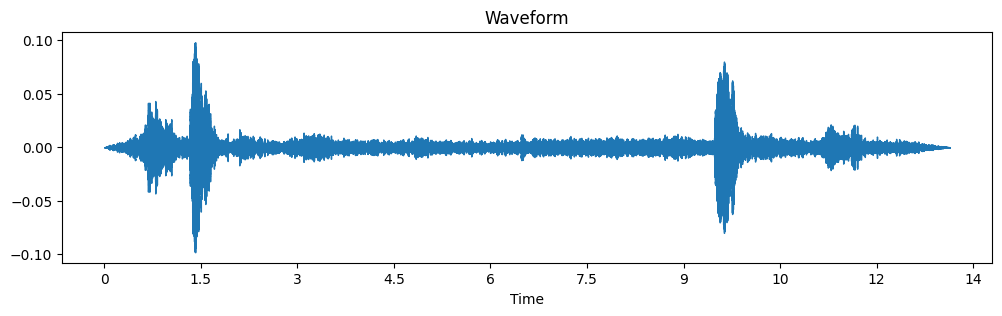

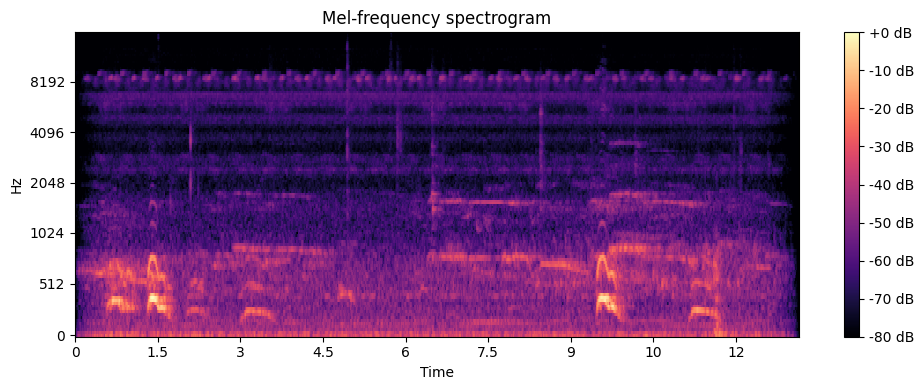

In [2]:
# @title Fetch an audio example. { vertical-output: true }

xeno_canto_id = 'xc1059809' #@param
sample_rate_hz = 32_000
frame_rate = 100


# (i) Load audio from Xeno-Canto given an ID like 'xc12345'
audio = audio_io.load_xc_audio(xeno_canto_id, sample_rate_hz)

#(ii) Load the audio file and return the signal as tensor and
#    the sample rate using Perch Hoplite load function
# sample_rate using Perch Hoplite load function
print(f"The shape of your audio tensor is : {audio.shape}")
#(ii) Display audio sound using Ipython display
ipy_display(IPython.display.Audio(audio, autoplay=True, rate=sample_rate_hz))
## Waveform of the audio
plt.figure(figsize=(12, 3))
librosa.display.waveshow(audio, sr=sample_rate_hz)
plt.title("Waveform")
plt.show()

# (iii) Plot a melspectrogram representing the audio
S = librosa.feature.melspectrogram(y=audio, sr=sample_rate_hz, n_mels=128)
S_dB = librosa.power_to_db(S, ref=np.max)

plt.figure(figsize=(10, 4))
librosa_display.specshow(S_dB, sr=sample_rate_hz, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel-frequency spectrogram')
plt.tight_layout()
plt.show()


Please answer the following questions:

#### Question 1

* What is the sample rate of your audio sample?
* How many channels does your audio sample contain?
* What is the shape of your audio tensor?
* Explain your interpretation of the melspectrogram displayed

ANSWER:
* The sample rate is 32,000 Hz (32 kHz).
* According to Xeno-Canto the audio sample contains 2 channels (stereo).
* The shape of your audio tensor is : (420474,).
* Explaination of my interpretation of the melspectrogram displayed:


This spectrogram shows a series of low-frequency pulsed harmonic vocalisations (light bands near the bottom) separated in time, as well as weaker energy at medium and high frequencies. The pattern corresponds to an owl's hooting/duet: a low fundamental with clear harmonics and repeated syllables.
The low fundamental, harmonics, and repeated hooting-like pulses are typical of calls (low-pitched, tonal).


#_Analysis of a window

In this section we select one window from our audio sound and smooth its values using the hanning window function

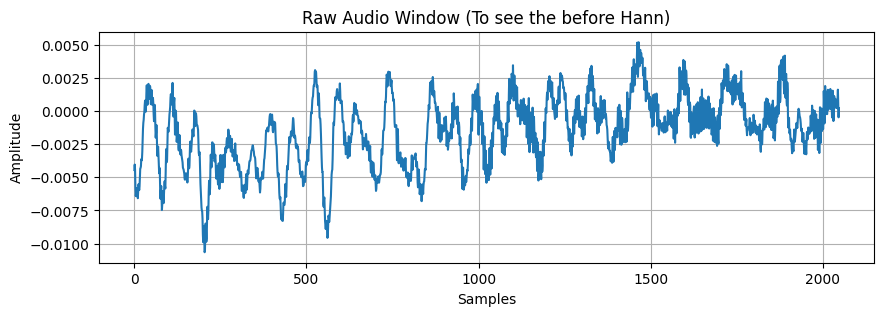

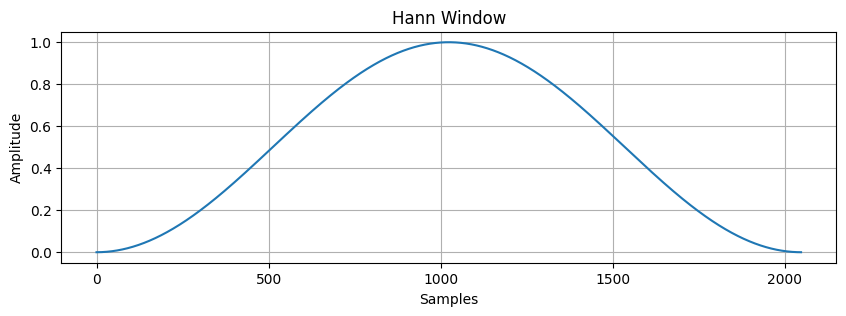

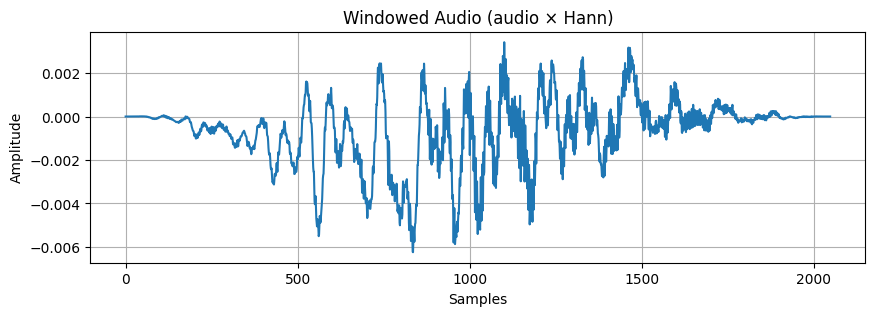

In [3]:
# @title Analyze one audio window. { vertical-output: true }

offset_s = 2.3  # @param
window_size = 2048  # @param

#(i) Select a sample window, starting at offset_s and with window_size samples, from the audio sound
# step = int(offset_s * sample_rate_hz)
step = int(offset_s * 32_000)

window = audio[step : step + window_size]

## Safety check: pad if audio is too short
if len(window) < window_size:
    window = np.pad(window, (0, window_size - len(window)))

#(ii) Load hanning window using scipy
hanning_window = hann(window_size)

## Apply windowing to the audio
windowed_audio = window * hanning_window

# (ii) Plot the sample window
plt.figure(figsize=(10, 3))
plt.plot(window)
plt.title("Raw Audio Window (To see the before Hann)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

## Plot the Hann window
plt.figure(figsize=(10, 3))
plt.plot(hanning_window)
plt.title("Hann Window")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

## Plot windowed audio
plt.figure(figsize=(10, 3))
plt.plot(windowed_audio)
plt.title("Windowed Audio (audio × Hann)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

#(iii) Display the sampled window using Ipython.display.Audio
ipy_display(IPython.display.Audio(windowed_audio, autoplay=True, rate=sample_rate_hz))


Question 2
* What is the purpose of smoothing the values using a windowing function?

ANSWER:
The purpose of smoothing values using a windowing function is to reduce spectral leakage when subsequently analysing  the audio in the frequency domain (e.g., with a Fourier transform).


   When taking a short audio segment, it is as if the signal is abruptly truncated. This sudden cut creates discontinuities at the edges of the window. Fourier analysis assumes that the signal is periodic, so these discontinuities introduce artificial frequencies (spectral leakage). We will see  extra frequency components appear that are not actually present in the original audio.

  Whereas a windowing function gradually attenuates the signal to zero at the edges. This reduces discontinuities and smooths the transitions at the beginning and end of the segment.

#Display frequency components of a window sample

In this section we apply discrete fourier transforms to analyze the frequency components of our audio sound

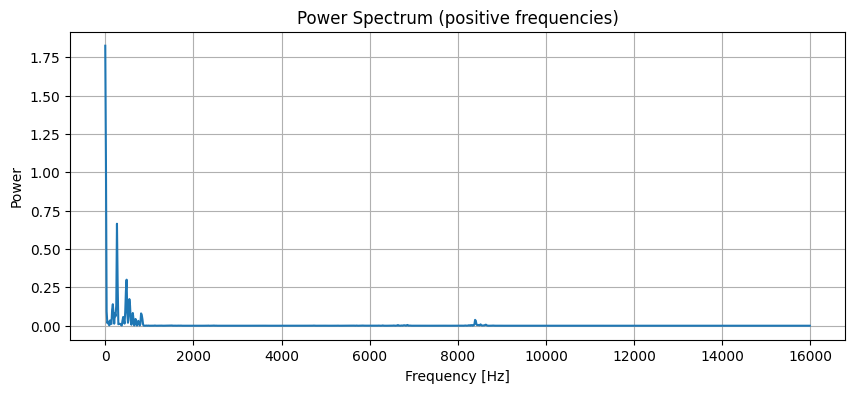

In [4]:
frame_window = hanning_window * window
dft_mat = scipy.linalg.dft(window_size)

#MY CODE GOES HERE

#(i) Compute the dft of the window sample
dft_window = dft_mat @ frame_window

#(ii) Convert the complexed valued output (i), into a power spectrum
power_spectrum = np.abs(dft_window)**2

#(iii) Select only the positive frequencies of your output
half = len(power_spectrum) // 2
freqs = np.fft.fftfreq(window_size, d=1/sample_rate_hz)
freqs_positive = freqs[:half]
power_positive = power_spectrum[:half]

#(iii) Plot the power spectrum using matplot lib
plt.figure(figsize=(10,4))
plt.plot(freqs_positive, power_positive)
plt.title("Power Spectrum (positive frequencies)")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Power")
plt.grid(True)
plt.show()

Text(0, 0.5, 'Power [dB]')

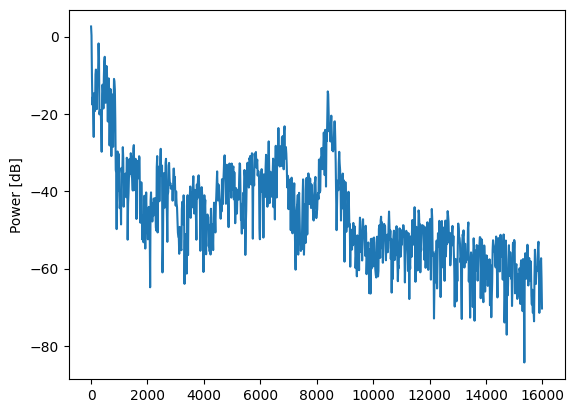

In [5]:
# spectrum in dB ( for a good view)
power_db = 10 * np.log10(power_positive + 1e-12)
plt.plot(freqs_positive, power_db)
plt.ylabel("Power [dB]")


Question 3

* Why do we convert complex valued output to a power spectrum?
* Why do we select only the positive frequencies of our power spectrum?


ANSWER:

 Why do we convert complex valued output to a power spectrum?

 The result of the Fourier transform is complex. We convert it to a power spectrum  to represent the energy of the signal at each frequency. The power spectrum therefore shows the amount of signal present at each frequency, which is easier to interpret and use for analysis than raw complex numbers.

 Why do we select only the positive frequencies of our power spectrum?

 For a real-valued signal, the Fourier transform is symmetric: the negative frequencies that are  the mirror image of the positive frequencies contain no new information. Therefore, it is sufficient to select only the positive frequencies to represent the full spectrum, which reduces redundancy and simplifies analysis.


#Create a MelFilterBank

The shape of the melfilterbank matrix is: (128, 1025)
[[-0.0000000e+00  1.9111710e-02  3.1723689e-02 ...  0.0000000e+00
   0.0000000e+00  0.0000000e+00]
 [ 0.0000000e+00  0.0000000e+00  3.2498667e-03 ...  0.0000000e+00
   0.0000000e+00  0.0000000e+00]
 [ 0.0000000e+00  0.0000000e+00  0.0000000e+00 ...  0.0000000e+00
   0.0000000e+00  0.0000000e+00]
 ...
 [ 0.0000000e+00  0.0000000e+00  0.0000000e+00 ...  0.0000000e+00
   0.0000000e+00  0.0000000e+00]
 [ 0.0000000e+00  0.0000000e+00  0.0000000e+00 ...  0.0000000e+00
   0.0000000e+00  0.0000000e+00]
 [ 0.0000000e+00  0.0000000e+00  0.0000000e+00 ...  1.4671341e-04
   7.3356707e-05  0.0000000e+00]]


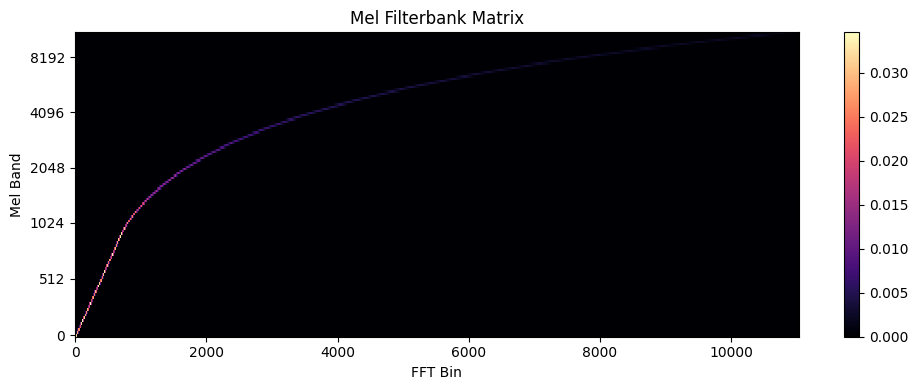

In [6]:
# (i) Create mel filterbank matrix
mel_mat = librosa.filters.mel(
    sr=sample_rate_hz,
    n_fft=window_size
)
print(f"The shape of the melfilterbank matrix is: {mel_mat.shape}")
print(mel_mat)
# (ii) Plot mel filterbank matrix
plt.figure(figsize=(10, 4))
librosa.display.specshow(
    mel_mat,
    x_axis='linear',
    y_axis='mel'
)
plt.colorbar()
plt.title('Mel Filterbank Matrix')
plt.xlabel('FFT Bin')
plt.ylabel('Mel Band')
plt.tight_layout()
plt.show()


Question 4
* What is the shape of the melfilterbank matrix?

ANSWER:  The shape of the melfilterbank matrix is: (128, 1025) that is (filtres, fréquences FFT)

#Apply Mel Matrix on Spectrogram

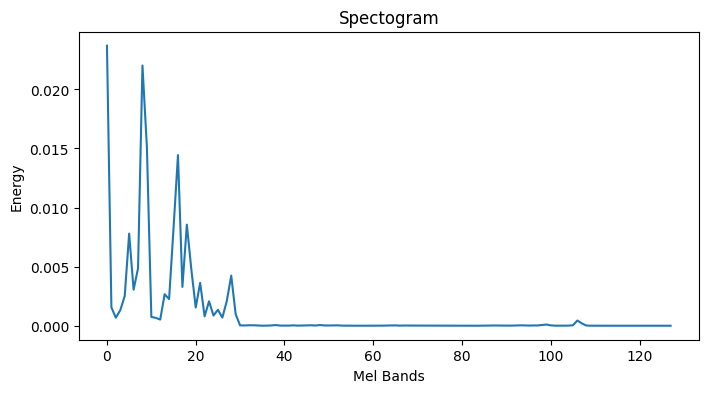

In [7]:
#(i) Apply the mel matrix to your spectrogram
mel_spec = np.dot(mel_mat, power_spectrum[:window_size//2 +1])
#(ii) Plot the output
plt.figure(figsize=(8, 4))
plt.plot(mel_spec)
plt.title("Spectogram")
plt.xlabel('Bands')
plt.ylabel('Energy')
plt.show()